C:\Users\tavis\Downloads\archive (1)
month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64
Order Date
2014-01-31     14236.8950
2014-02-28      4519.8920
2014-03-31     55691.0090
2014-04-30     28295.3450
2014-05-31     23648.2870
2014-06-30     34595.1276
2014-07-31     33946.3930
2014-08-31     27909.4685
2014-09-30     81777.3508
2014-10-31     31453.3930
2014-11-30     78628.7167
2014-12-31     69545.6205
2015-01-31     18174.0756
2015-02-28     11951.4110
2015-03-31     38726.2520
2015-04-30     34195.2085
2015-05-31     30131.6865
2015-06-30     24797.2920
2015-07-31     28765.3250
2015-08-31     36898.3322
2015-09-30     64595.9180
2015-10-31     31404.9235
2015-11-30     75972.5635
2015-12-31     74919.5212
2016-01-31     18542.4910
2016-02-29     22978.8150
2016-03-31     51715.8750


<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\tavis\AppData\Local\Temp\ipykernel_10652\3304809766.py:7: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_csv("C:/Users/tavis\Downloads/archive (1)/Sample - Superstore.csv", encoding='ISO-8859-1')


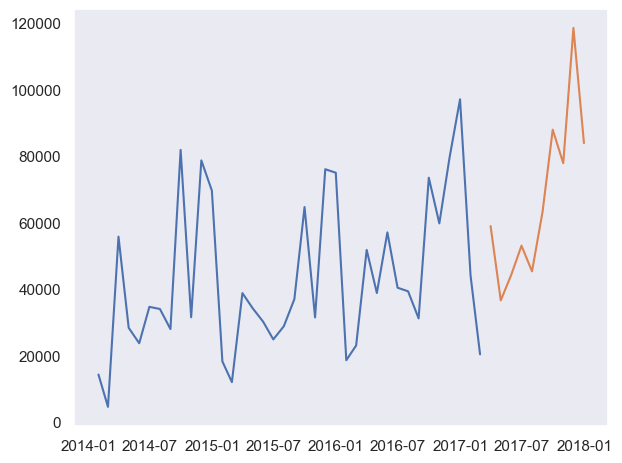

In [16]:

import zipfile

with zipfile.ZipFile(r'C:/Users/tavis/Downloads/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:/Users/tavis/Downloads/archive (1)')
    %cd C:\Users\tavis\Downloads\archive (1)
import pandas as pd
df=pd.read_csv("C:/Users/tavis\Downloads/archive (1)/Sample - Superstore.csv", encoding='ISO-8859-1')

df
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month']=df['Order Date'].dt.month
df
results=df.groupby('month')['Sales'].sum()
print(results)

monthly=df.resample('ME', on='Order Date')['Sales'].sum()
print(monthly)


from matplotlib import pyplot as plt

split = int(len(monthly) * 0.8)
train = monthly[:split]
plt.plot(train)
test = monthly[split:]
plt.plot(test)
plt.tight_layout()
plt.grid()
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
def evaluate(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual-predicted)/actual))*100
    return {'RMSE':round(rmse,2), 'MAE':round(mae,2), 'MAPE':round(mape,2)}

In [18]:
from pmdarima import auto_arima

model_arima = auto_arima(
    train,
    seasonal=True,
    m=12,              
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    max_p=3, max_q=3,  
    max_P=2, max_Q=2,
    D=0,              
    error_action='ignore'
)

print(model_arima.summary())
forecast_arima = model_arima.predict(n_periods=len(test))

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                   38
Model:             SARIMAX(0, 0, 1)x(0, 0, [1, 2], 12)   Log Likelihood                -427.092
Date:                                 Tue, 05 May 2026   AIC                            864.183
Time:                                         19:41:46   BIC                            872.371
Sample:                                     01-31-2014   HQIC                           867.096
                                          - 02-28-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.353e+04   9698.121      4.488      0.000    2.45e+04    6.25

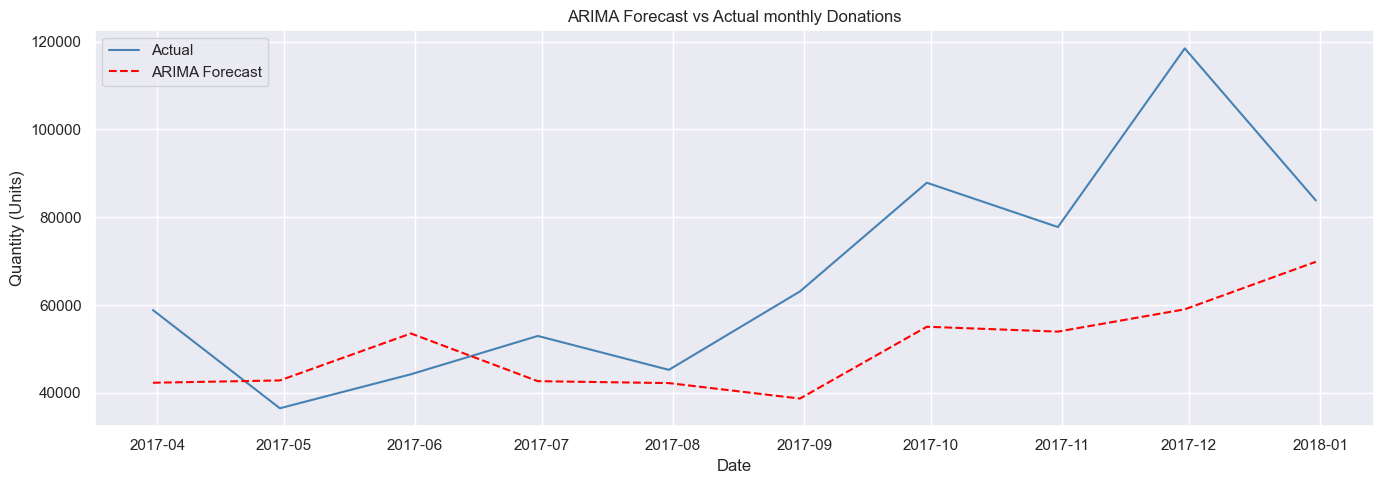

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

fig, ax = plt.subplots(figsize=(14, 5))

# "actual test" = the real donation values from your held-out test period
ax.plot(test.index, test.values, color='steelblue', linewidth=1.5, label='Actual')

# "ARIMA forecast" = what your model predicted for those same weeks
ax.plot(test.index, forecast_arima, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')

ax.set_title('ARIMA Forecast vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()

plt.show()

In [22]:
arima_metrics = evaluate(test.values, forecast_arima)
results['ARIMA'] = arima_metrics
print(results)

month
1                                               94924.8356
2                                               59751.2514
3                                              205005.4888
4                                              137762.1286
5                                              155028.8117
6                                              152718.6793
7                                               147238.097
8                                               159044.063
9                                              307649.9457
10                                             200322.9847
11                                              352461.071
12                                             325293.5035
ARIMA    {'RMSE': 25445.61, 'MAE': 19981.86, 'MAPE': 26...
Name: Sales, dtype: object


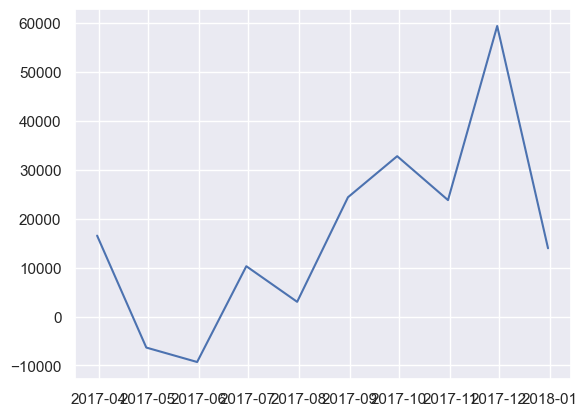

In [24]:
residuals = test.values - forecast_arima
plt.plot(residuals)
plt.tight_layout
plt.show()



In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_ets = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_ets = model_ets.forecast(len(test))
ets_metrics = evaluate(test.values, forecast_ets.values)
results['ETS'] = ets_metrics
print(results)

month
1                                               94924.8356
2                                               59751.2514
3                                              205005.4888
4                                              137762.1286
5                                              155028.8117
6                                              152718.6793
7                                               147238.097
8                                               159044.063
9                                              307649.9457
10                                             200322.9847
11                                              352461.071
12                                             325293.5035
ARIMA    {'RMSE': 25445.61, 'MAE': 19981.86, 'MAPE': 26...
ETS      {'RMSE': 12396.26, 'MAE': 11175.29, 'MAPE': 18...
Name: Sales, dtype: object


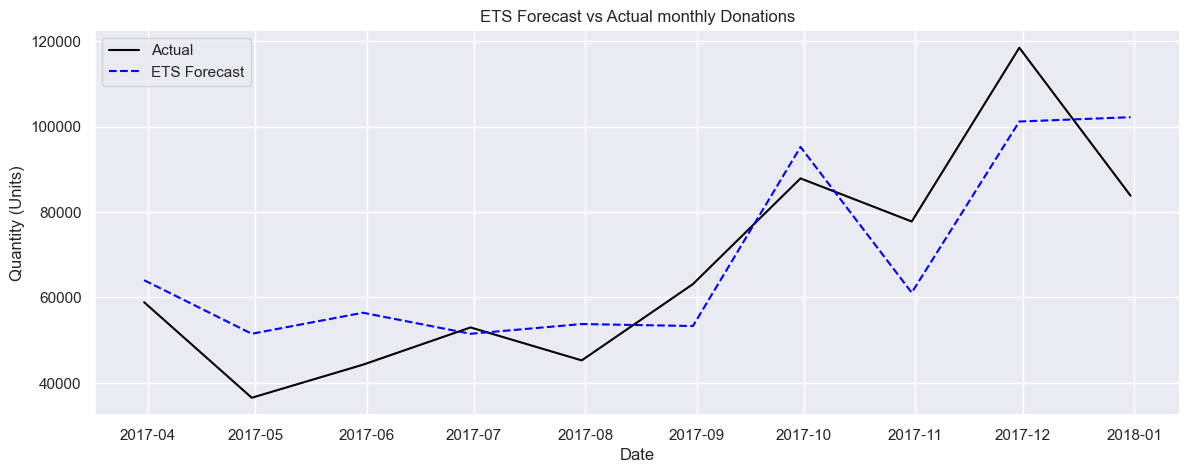

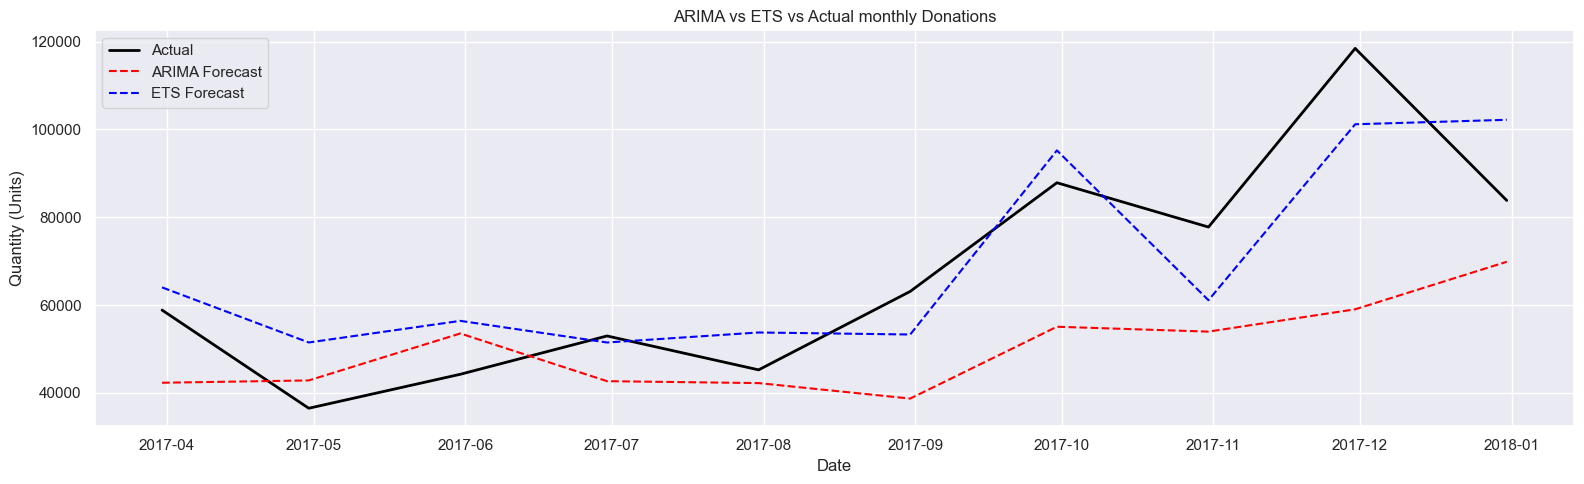

In [29]:

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# --- fig7: ETS forecast vs actual ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, test.values, color='black', linewidth=1.5, label='Actual')
ax.plot(test.index, forecast_ets.values, color='blue', linestyle='--', linewidth=1.5, label='ETS Forecast')

ax.set_title('ETS Forecast vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()

plt.show()

# --- fig8: ARIMA vs ETS vs Actual ---
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(test.index, test.values, color='black', linewidth=2, label='Actual')
ax.plot(test.index, forecast_arima, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')
ax.plot(test.index, forecast_ets.values, color='blue', linestyle='--', linewidth=1.5, label='ETS Forecast')

ax.set_title('ARIMA vs ETS vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()

plt.show()

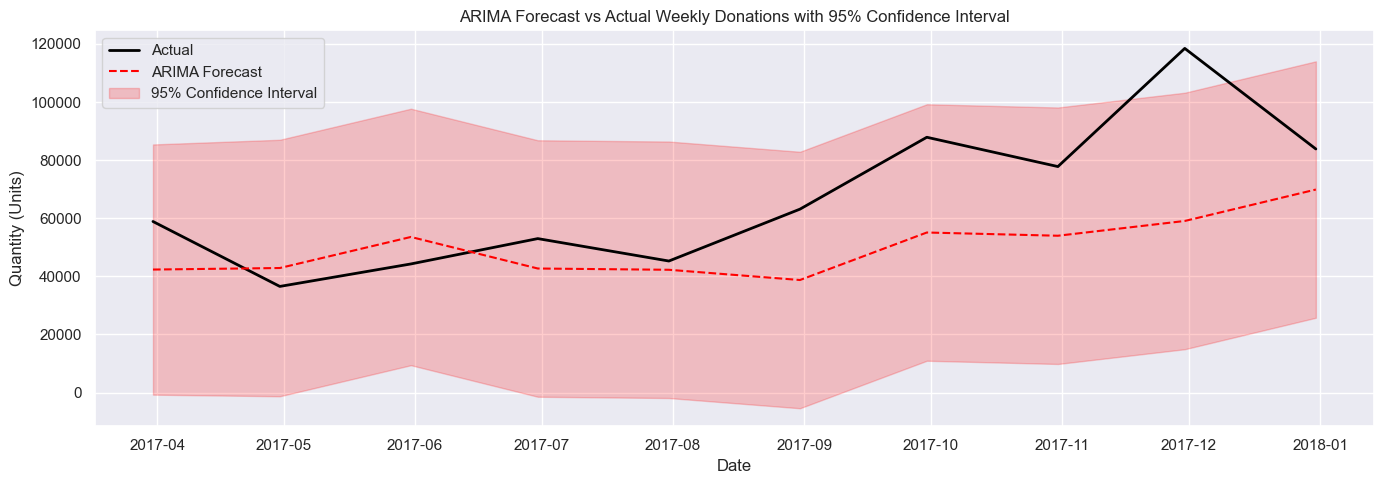

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Get forecast with confidence intervals
forecast_ci, conf_int = model_arima.predict(n_periods=len(test), return_conf_int=True)

fig, ax = plt.subplots(figsize=(14, 5))

# Actual test values
ax.plot(test.index, test.values, color='black', linewidth=2, label='Actual')

# ARIMA forecast line
ax.plot(test.index, forecast_ci, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')

# Confidence band (shaded region)
ax.fill_between(test.index, conf_int[:, 0], conf_int[:, 1],
                alpha=0.2, color='red', label='95% Confidence Interval')

ax.set_title('ARIMA Forecast vs Actual Weekly Donations with 95% Confidence Interval')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()
plt.show()
